Install all required Libraries

In [2]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import confusion_matrix, classification_report
import pandas as pd
import joblib
import matplotlib.pyplot as plt

Load Data

In [3]:
data = pd.read_csv("creditcard.csv")

Learn Data

In [4]:
print("Shape: ", data.shape)
print("Info: ", data.info)
print("Columns: ", data.columns.tolist())

Shape:  (284807, 31)
Info:  <bound method DataFrame.info of             Time         V1         V2        V3        V4        V5  \
0            0.0  -1.359807  -0.072781  2.536347  1.378155 -0.338321   
1            0.0   1.191857   0.266151  0.166480  0.448154  0.060018   
2            1.0  -1.358354  -1.340163  1.773209  0.379780 -0.503198   
3            1.0  -0.966272  -0.185226  1.792993 -0.863291 -0.010309   
4            2.0  -1.158233   0.877737  1.548718  0.403034 -0.407193   
...          ...        ...        ...       ...       ...       ...   
284802  172786.0 -11.881118  10.071785 -9.834783 -2.066656 -5.364473   
284803  172787.0  -0.732789  -0.055080  2.035030 -0.738589  0.868229   
284804  172788.0   1.919565  -0.301254 -3.249640 -0.557828  2.630515   
284805  172788.0  -0.240440   0.530483  0.702510  0.689799 -0.377961   
284806  172792.0  -0.533413  -0.189733  0.703337 -0.506271 -0.012546   

              V6        V7        V8        V9  ...       V21       V22  \


Seprate X and Y

In [5]:
x = data.drop(["Time", "Class"], axis=1)
y = data["Class"]

Split Training and Testing Data

In [6]:
x_train, x_test, y_train, y_test = train_test_split(
    x,
    y,
    random_state=1,
    test_size=0.3
)

Create and Train Model

In [7]:
model = RandomForestClassifier(random_state=1)
model.fit(x_train, y_train)

,"random_state random_state: int, RandomState instance or None, default=NoneControls both the randomness of the bootstrapping of the samples usedwhen building trees (if ``bootstrap=True``) and the sampling of thefeatures to consider when looking for the best split at each node(if ``max_features < n_features``).See :term:`Glossary <random_state>` for details.",1
,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstra

Predict, Classification Report, Confusion Matrix

In [8]:
prediction = model.predict(x_test)
CR = classification_report(y_test, prediction)
CM = confusion_matrix(y_test, prediction)

print(f"Prediction: {prediction}")
print(f"Classification report:\n{CR}")
print(f"Confusion matrix:\n{CM}")

Prediction: [0 0 0 ... 0 0 0]
Classification report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     85308
           1       0.91      0.79      0.84       135

    accuracy                           1.00     85443
   macro avg       0.96      0.89      0.92     85443
weighted avg       1.00      1.00      1.00     85443

Confusion matrix:
[[85298    10]
 [   29   106]]


Visualize

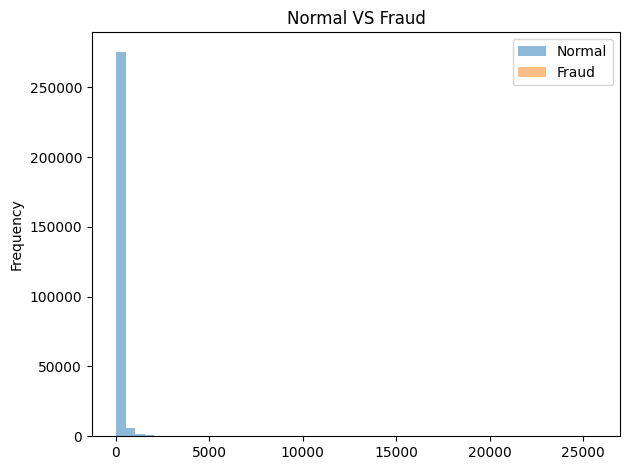

In [11]:
plt.figure()

data[data["Class"] == 0]["Amount"].plot(kind="hist", bins=50, alpha=0.5, label="Normal")

data[data["Class"] == 1]["Amount"].plot(kind="hist", bins=50, alpha=0.5, label="Fraud")

plt.legend()
plt.title("Normal VS Fraud")
plt.tight_layout()
plt.show()

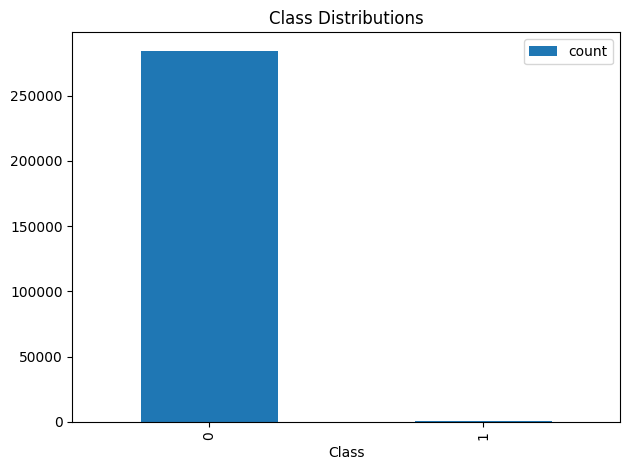

In [13]:
data["Class"].value_counts().plot(kind="bar")
plt.title("Class Distributions")
plt.tight_layout()
plt.legend()
plt.show()

C:\Users\jayes\AppData\Local\Temp\ipykernel_19564\2388901414.py:3: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


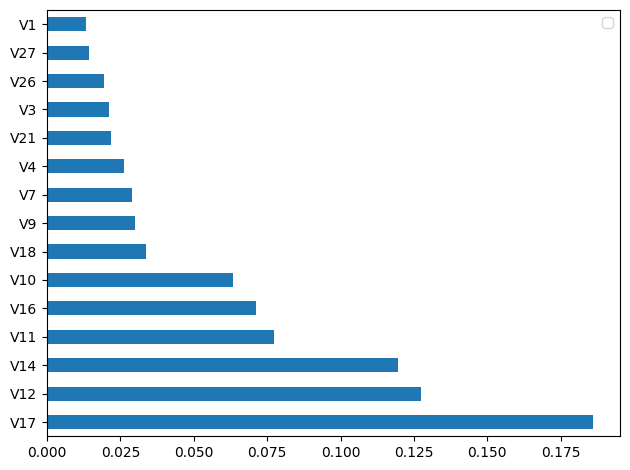

In [15]:
featimp = pd.Series(model.feature_importances_, index=x.columns)
featimp.nlargest(15).plot(kind="barh")
plt.legend()
plt.tight_layout()
plt.show()

Save Model For Deployment etc.

In [16]:
joblib.dump(model, "FraudDetectionModel.pkl")
print("Model Saved")

Model Saved


Load Model

In [17]:
joblib.load("FraudDetectionModel.pkl")
print("Model Loaded")

Model Loaded
